## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Configure display and plotting
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
warnings.filterwarnings('ignore')

%matplotlib inline

## 1. Load Data

In [ ]:
# Load dataset
data_path = Path('../data/raw/2025_(JAN-MAR).csv')

# Read with date parsing
df = pd.read_csv(
    data_path,
    parse_dates=['Published Date', 'Closing Date', 'Award Date', 
                 'Published Date (Award)', 'Notice to Proceed Date',
                 'Contract Effectivity Date', 'Contract End Date']
)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset loaded: 299 rows × 46 columns
Memory usage: 0.66 MB


## 2. Initial Inspection

In [3]:
# Display first few rows
df.head()

,Procuring Entity,Region,Province,City/Municipality,Government Branch,PE Organization Type,PE Organization Type (Grouped),Bid Reference No.,Notice Title,Classification,Procurement Mode,Business Category,Source of Funds,Trade Agreement,Approved Budget of the Contract (ABC),Published Date,Closing Date,Area of Delivery,Contract Duration,Calendar Type,Lot Type,Item Code,Item/Lot Name,Item/Lot Description,Quantity,Unit of Measure,Item Budget,Bid Notice Status,Award Reference No.,Award Title,UNSPSC Code,UNSPSC Description,Published Date (Award),Award Date,Contract Amount,Award Notice Status,Notice to Proceed Date,Contract Effectivity Date,Contract End Date,Awardee Organization Name,Country of Awardee,Region of Awardee,Province of Awardee,City/Municipality of Awardee,Awardee Size,Awardee Joint Venture
0,PHILIPPINE COMMISSION ON SPORTS SCUBA DIVING,NCR,Metro Manila,Makati City,Executive,Attached Agency,National Government Agencies (NGA),3827,Conduct of BOT Regular/Special Meeting,Goods,Small Value Procurement,Travel facilitation,Regular Agency Fund (01000000),Implementing Rules and Regulations,151500.0,2025-01-16,2025-01-20,Metro Manila,3,days,Single Lot,90121502,Travel agencies,Procurement of Travel and Tour Services for\r\...,1,Lot,0.0,Closed,1365,Conduct of BOT Regular/Special Meeting,90121502,Travel agencies,2025-02-21,2025-01-20,151500.0,Posted/Published,NaT,NaT,NaT,EAS - ELLEN'S TRAVEL & TOURS,Philippines,Region IV-B,Palawan,Puerto Princesa City,Micro,NaN
1,DEPARTMENT OF PUBLIC WORKS AND HIGHWAYS - MAIN,NCR,Metro Manila,Manila,Executive,Department,National Government Agencies (NGA),3843,CONSULTING SERVICES FOR THE CONSTRUCTION SUPER...,Consulting Services,Public Bidding,Professional engineering services,Regular Agency Fund (01000000),Implementing Rules and Regulations,571629232.5,2025-01-17,2025-02-27,NaN,44,months,Single Lot,81101505,Structural engineering,Structural engineering,1,Lot,0.0,Closed,1669,CONSULTING SERVICES FOR THE CONSTRUCTION SUPER...,81101508,Architectural engineering,2025-07-15,2025-07-15,535456140.0,Posted/Published,NaT,NaT,NaT,WOODFIELDS ENGINEERS COMPANY,Philippines,Region IV-A,Rizal,Rodriguez (Montalban),Medium,NaN
2,DEPARTMENT OF PUBLIC WORKS AND HIGHWAYS - MAIN,NCR,Metro Manila,Manila,Executive,Department,National Government Agencies (NGA),3843,CONSULTING SERVICES FOR THE CONSTRUCTION SUPER...,Consulting Services,Public Bidding,Professional engineering services,Regular Agency Fund (01000000),Implementing Rules and Regulations,571629232.5,2025-01-17,2025-02-27,NaN,44,months,Single Lot,81101505,Structural engineering,Structural engineering,1,Lot,0.0,Closed,1669,CONSULTING SERVICES FOR THE CONSTRUCTION SUPER...,81101526,Quantity surveying service,2025-07-15,2025-07-15,535456140.0,Posted/Published,NaT,NaT,NaT,WOODFIELDS ENGINEERS COMPANY,Philippines,Region IV-A,Rizal,Rodriguez (Montalban),Medium,NaN
3,DEPARTMENT OF PUBLIC WORKS AND HIGHWAYS - MAIN,NCR,Metro Manila,Manila,Executive,Department,National Government Agencies (NGA),3843,CONSULTING SERVICES FOR THE CONSTRUCTION SUPER...,Consulting Services,Public Bidding,Professional engineering services,Regular Agency Fund (01000000),Implementing Rules and Regulations,571629232.5,2025-01-17,2025-02-27,NaN,44,months,Single Lot,81101505,Structural engineering,Structural engineering,1,Lot,0.0,Closed,1669,CONSULTING SERVICES FOR THE CONSTRUCTION SUPER...,81101510,Highway engineering,2025-07-15,2025-07-15,535456140.0,Posted/Published,NaT,NaT,NaT,WOODFIELDS ENGINEERS COMPANY,Philippines,Region IV-A,Rizal,Rodriguez (Montalban),Medium,NaN
4,DEPARTMENT OF PUBLIC WORKS AND HIGHWAYS - MAIN,NCR,Metro Manila,Manila,Executive,Department,National Government Agencies (NGA),3843,CONSULTING SERVICES FOR THE CONSTRUCTION SUPER...,Consulting Services,Public Bidding,Professional engineering services,Regular Agency Fund (01000000),Implementing Rules and Regulations,571629232.5,2025-01-17,2025-02-27,NaN,44,months,Single Lot,81101505,Structural engineering,Structural engineering,1,Lot,0.0

In [4]:
# Column names and types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 46 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Procuring Entity                       299 non-null    str           
 1   Region                                 299 non-null    str           
 2   Province                               299 non-null    str           
 3   City/Municipality                      299 non-null    str           
 4   Government Branch                      299 non-null    str           
 5   PE Organization Type                   299 non-null    str           
 6   PE Organization Type (Grouped)         299 non-null    str           
 7   Bid Reference No.                      299 non-null    int64         
 8   Notice Title                           299 non-null    str           
 9   Classification                         299 non-null    str           
 10  P

In [5]:
# Summary statistics for numerical columns
df.describe()

,Bid Reference No.,Approved Budget of the Contract (ABC),Published Date,Closing Date,Contract Duration,Item Code,Quantity,Item Budget,Award Reference No.,UNSPSC Code,Published Date (Award),Award Date,Contract Amount,Notice to Proceed Date,Contract Effectivity Date,Contract End Date,Awardee Joint Venture
count,299.000000,2.990000e+02,299,299,299.000000,2.990000e+02,299.000000,299.000000,299.000000,2.990000e+02,299,299,2.990000e+02,33,33,33,0.0
mean,4189.732441,1.922331e+08,2025-02-13 18:27:41.538461,2025-03-04 15:15:03.010033,30.612040,5.963911e+07,2312.000000,49975.976589,1557.806020,5.963911e+07,2025-05-09 19:44:44.949832,2025-05-01 23:40:44.147157,1.799017e+08,2025-03-29 10:10:54.545454,2025-03-30 09:27:16.363636,2025-07-22 19:38:10.909091,NaN
min,3827.000000,4.825000e+04,2025-01-16 00:00:00,2025-01-20 00:00:00,1.000000,1.019151e+07,1.000000,0.000000,1340.000000,1.019151e+07,2025-02-12 00:00:00,2025-01-20 00:00:00,4.112500e+04,2025-02-10 00:00:00,2025-02-10 00:00:00,2025-02-12 00:00:00,NaN
25%,3843.000000,1.397050e+05,2025-01-17 00:00:00,2025-02-21 00:00:00,30.000000,4.410310e+07,1.000000,0.000000,1527.000000,4.410310e+07,2025-04-02 00:00:00,2025-03-13 00:00:00,1.157554e+05,2025-03-20 00:00:00,2025-03-27 00:00:00,2025-04-22 00:00:00,NaN
50%,4123.000000,6.993290e+05,2025-02-13 00:00:00,2025-02-27 00:00:00,30.000000,5.510152e+07,1.000000,0.000000,1561.000000,5.510152e+07,2025-04-24 00:00:00,2025-04-10 00:00:00,2.310000e+05,2025-04-07 00:00:00,2025-04-07 00:00:00,2025-04-22 00:00:00,NaN
75%,4524.000000,5.716292e+08,2025-03-11 00:00:00,2025-03-24 00:00:00,44.000000,8.110151e+07,4.000000,0.000000,1669.000000,8.110151e+07,2025-07-15 00:00:00,2025-07-15 00:00:00,5.354561e+08,2025-04-07 00:00:00,2025-04-07 00:00:00,2026-02-27 00:00:00,NaN
max,4867.000000,5.716292e+08,2025-03-31 00:00:00,2025-04-28 00:00:00,120.000000,9.212150e+07,202000.000000,1000000.000000,1675.000000,9.212150e+07,2025-07-22 00:00:00,2025-07-15 00:00:00,5.354561e+08,2025-04-25 00:00:00,2025-04-26 00:00:00,2026-03-16 00:00:00,NaN
std,331.955567,2.694702e+08,NaN,NaN,15.295632,2.199559e+07,17115.296246,144176.068324,105.844839,2.199559e+07,NaN,NaN,2.525326e+08,NaN,NaN,NaN,NaN


## 3. Data Quality Assessment

In [6]:
# Missing values analysis
missing = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Count', ascending=False)

print("\nMissing Values Summary:")
print(missing[missing['Missing_Count'] > 0])


Missing Values Summary:
                                                    Column  Missing_Count  \
Awardee Joint Venture                Awardee Joint Venture            299   
Contract Effectivity Date        Contract Effectivity Date            266   
Contract End Date                        Contract End Date            266   
Notice to Proceed Date              Notice to Proceed Date            266   
Area of Delivery                          Area of Delivery            106   
Province of Awardee                    Province of Awardee              3   
Country of Awardee                      Country of Awardee              3   
Region of Awardee                        Region of Awardee              3   
City/Municipality of Awardee  City/Municipality of Awardee              3   

                              Missing_Percent  
Awardee Joint Venture                  100.00  
Contract Effectivity Date               88.96  
Contract End Date                       88.96  
Notice to Pr

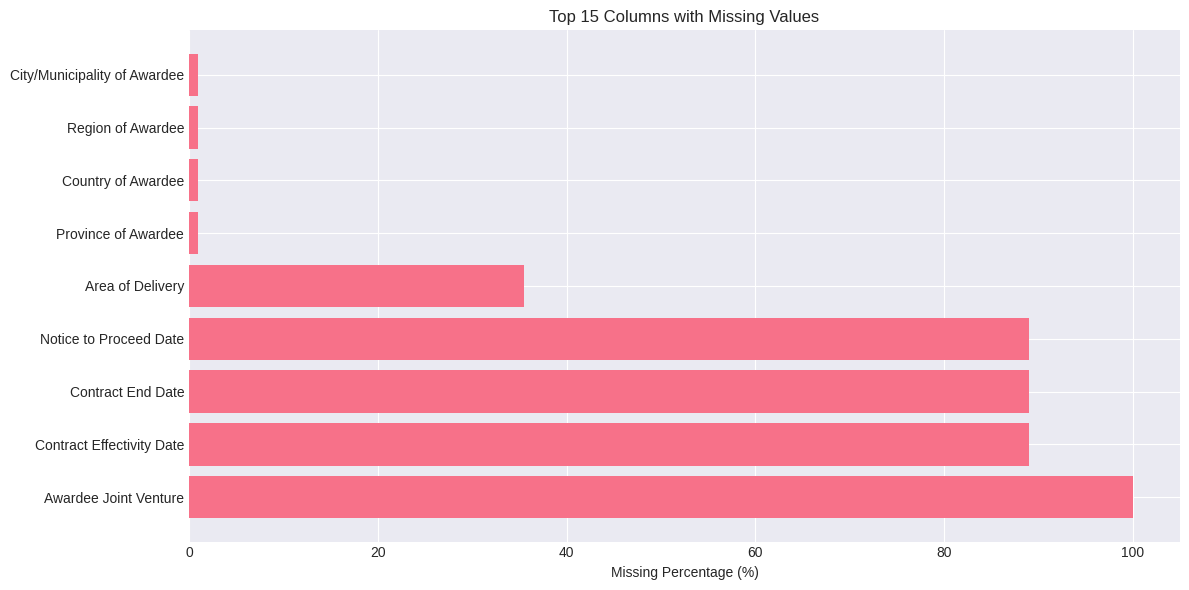

In [7]:
# Visualize missing data
plt.figure(figsize=(12, 6))
missing_cols = missing[missing['Missing_Count'] > 0].head(15)
plt.barh(missing_cols['Column'], missing_cols['Missing_Percent'])
plt.xlabel('Missing Percentage (%)')
plt.title('Top 15 Columns with Missing Values')
plt.tight_layout()
plt.show()

In [8]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nTotal duplicate rows: {duplicates}")

# Check duplicates by Bid Reference
bid_duplicates = df['Bid Reference No.'].value_counts()
print(f"\nBids with multiple entries: {(bid_duplicates > 1).sum()}")
print("\nTop 5 most repeated bids:")
print(bid_duplicates.head())


Total duplicate rows: 126

Bids with multiple entries: 16

Top 5 most repeated bids:
Bid Reference No.
3843    100
4669     36
4044     32
4206     25
4524     20
Name: count, dtype: int64


## 4. Key Features Exploration

### 4.1 Financial Features

In [9]:
# ABC and Contract Amount analysis
print("Approved Budget of Contract (ABC):")
print(df['Approved Budget of the Contract (ABC)'].describe())
print("\nContract Amount:")
print(df['Contract Amount'].describe())

Approved Budget of Contract (ABC):
count    2.990000e+02
mean     1.922331e+08
std      2.694702e+08
min      4.825000e+04
25%      1.397050e+05
50%      6.993290e+05
75%      5.716292e+08
max      5.716292e+08
Name: Approved Budget of the Contract (ABC), dtype: float64

Contract Amount:
count    2.990000e+02
mean     1.799017e+08
std      2.525326e+08
min      4.112500e+04
25%      1.157554e+05
50%      2.310000e+05
75%      5.354561e+08
max      5.354561e+08
Name: Contract Amount, dtype: float64


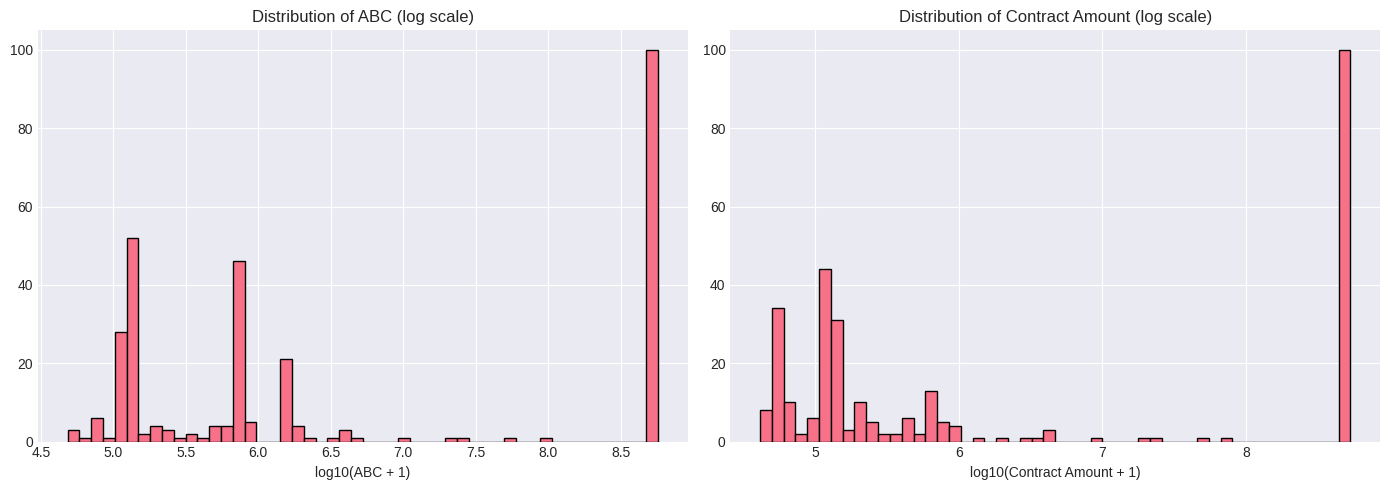

In [10]:
# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ABC distribution (log scale)
df['Approved Budget of the Contract (ABC)'].apply(lambda x: np.log10(x + 1)).hist(
    bins=50, ax=axes[0], edgecolor='black'
)
axes[0].set_title('Distribution of ABC (log scale)')
axes[0].set_xlabel('log10(ABC + 1)')

# Contract Amount distribution (log scale)
df['Contract Amount'].apply(lambda x: np.log10(x + 1)).hist(
    bins=50, ax=axes[1], edgecolor='black'
)
axes[1].set_title('Distribution of Contract Amount (log scale)')
axes[1].set_xlabel('log10(Contract Amount + 1)')

plt.tight_layout()
plt.show()

### 4.2 Temporal Features

In [11]:
# Timeline analysis
print("Published Date range:")
print(f"From: {df['Published Date'].min()}")
print(f"To: {df['Published Date'].max()}")
print(f"\nAward Date range:")
print(f"From: {df['Award Date'].min()}")
print(f"To: {df['Award Date'].max()}")

Published Date range:
From: 2025-01-16 00:00:00
To: 2025-03-31 00:00:00

Award Date range:
From: 2025-01-20 00:00:00
To: 2025-07-15 00:00:00


In [ ]:
# Procurement timeline over months
df['Published_Month'] = df['Published Date'].dt.to_period('M')
monthly_counts = df.groupby('Published_Month').size()

plt.figure(figsize=(10, 5))
monthly_counts.plot(kind='bar')
plt.title('Procurement Activities by Month')
plt.xlabel('Month')
plt.ylabel('Number of Bids')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.3 Categorical Features

In [ ]:
# Procurement Mode distribution
print("Procurement Mode:")
print(df['Procurement Mode'].value_counts())

plt.figure(figsize=(10, 5))
df['Procurement Mode'].value_counts().plot(kind='barh')
plt.title('Distribution of Procurement Modes')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
# Classification distribution
print("\nClassification:")
print(df['Classification'].value_counts())

In [ ]:
# Top procuring entities
print("\nTop 10 Procuring Entities:")
print(df['Procuring Entity'].value_counts().head(10))

In [ ]:
# Top awardees
print("\nTop 10 Awardees:")
print(df['Awardee Organization Name'].value_counts().head(10))

## 5. Initial Anomaly Indicators

Let's create some preliminary features to explore potential anomalies.

In [ ]:
# Create derived features
df_analysis = df.copy()

# Price variance
df_analysis['Price_Variance_Pct'] = (
    (df_analysis['Contract Amount'] - df_analysis['Approved Budget of the Contract (ABC)']) / 
    df_analysis['Approved Budget of the Contract (ABC)'] * 100
)

# Bidding duration (days)
df_analysis['Bidding_Duration_Days'] = (
    df_analysis['Closing Date'] - df_analysis['Published Date']
).dt.days

# Award speed (days)
df_analysis['Award_Speed_Days'] = (
    df_analysis['Award Date'] - df_analysis['Closing Date']
).dt.days

print("Derived features created successfully!")

In [ ]:
# Explore price variance
print("Price Variance Statistics:")
print(df_analysis['Price_Variance_Pct'].describe())

plt.figure(figsize=(10, 5))
df_analysis['Price_Variance_Pct'].hist(bins=50, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='No variance')
plt.title('Distribution of Price Variance (%)')
plt.xlabel('Price Variance (%)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Extreme price variances (potential anomalies)
extreme_variance = df_analysis[
    (df_analysis['Price_Variance_Pct'] < -50) | 
    (df_analysis['Price_Variance_Pct'] > 50)
]
print(f"\nBids with extreme price variance (>50% or <-50%): {len(extreme_variance)}")
print("\nSample of extreme variances:")
print(extreme_variance[[
    'Bid Reference No.', 'Notice Title', 'Approved Budget of the Contract (ABC)', 
    'Contract Amount', 'Price_Variance_Pct'
]].head(10))

In [ ]:
# Explore bidding duration
print("\nBidding Duration Statistics (days):")
print(df_analysis['Bidding_Duration_Days'].describe())

# Flag suspiciously short bidding periods
short_bidding = df_analysis[df_analysis['Bidding_Duration_Days'] < 7]
print(f"\nBids with <7 days bidding period: {len(short_bidding)}")

In [ ]:
# Explore award speed
print("\nAward Speed Statistics (days):")
print(df_analysis['Award_Speed_Days'].describe())

# Flag suspiciously fast awards
fast_awards = df_analysis[df_analysis['Award_Speed_Days'] < 1]
print(f"\nBids awarded in <1 day: {len(fast_awards)}")

## 6. Key Insights & Next Steps

### Summary of Findings
*(This will be filled after running the analysis)*

### Data Quality Issues to Address
- [ ] Missing values in timeline columns
- [ ] Duplicate entries (same bid, multiple UNSPSC codes)
- [ ] Zero values in Item Budget

### Next Steps
1. **Notebook 02:** Data preprocessing and cleaning
2. Deduplication strategy
3. Feature engineering for all derived features
4. Handle missing values

---
**End of Exploratory Data Analysis**